# SVI Volatility Surface

## The SVI Parametrization

The **Stochastic Volatility Inspired (SVI)** model (Gatheral 2004) parametrizes the total implied variance
$w(k) = \sigma_{\text{imp}}^2(k) \cdot T$ as a function of log-moneyness $k = \ln(K/F)$:

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k - m)^2 + \sigma^2}\right]$$

| Parameter | Role |
|-----------|------|
| $a$       | Overall variance level (vertical shift) |
| $b$       | Angle of the wings |
| $\rho$    | Skew (left/right asymmetry, $\rho \in (-1, 1)$) |
| $m$       | Horizontal translation of the minimum |
| $\sigma$  | Curvature (ATM smoothness) |

Implied volatility is recovered as $\sigma_{\text{imp}}(K, T) = \sqrt{w(k) / T}$.

## Workflow

1. **`SVISlice`** — a single expiry slice; evaluates total variance and implied vol for any strike.
2. **`SVICalibrator`** — fits an `SVISlice` to market quotes by minimizing squared vol error (L-BFGS-B).
3. **`SVISurface`** — holds calibrated slices across expiries; interpolates total variance linearly in time for in-between expiries.

In [1]:
from neon.lib.instruments.surface.svi import SVISlice, SVICalibrator, SVISurface
import matplotlib.pyplot as plt
import numpy as np

# Common market data used throughout the notebook
forward = 100.0
strikes = [80, 85, 90, 95, 100, 105, 110, 115, 120]

expiry1 = "20260101"
T1 = 1.0
vols1 = [0.25, 0.23, 0.21, 0.20, 0.20, 0.21, 0.22, 0.23, 0.25]

expiry2 = "20270101"
T2 = 2.0
vols2 = [0.24, 0.22, 0.21, 0.20, 0.20, 0.20, 0.21, 0.22, 0.24]

## 1. SVISlice — Evaluating a Parametric Smile

We construct an `SVISlice` manually with reasonable parameters and inspect the smile it produces.

In [2]:
# Manual slice with chosen params
manual_slice = SVISlice(a=0.04, b=0.1, rho=-0.3, m=0.0, sigma=0.2)

print("SVISlice params:")
print(f"  a={manual_slice.a}, b={manual_slice.b}, rho={manual_slice.rho},"
      f" m={manual_slice.m}, sigma={manual_slice.sigma}")
print()

print(f"{'Strike':>8}  {'LogMon':>8}  {'TotalVar':>10}  {'ImplVol':>9}")
print("-" * 42)
for K in strikes:
    lm = np.log(K / forward)
    tv = manual_slice.total_variance(K, forward)
    iv = manual_slice.implied_vol(K, forward, T1)
    print(f"{K:>8}  {lm:>8.4f}  {tv:>10.6f}  {iv:>9.4f}")

SVISlice params:
  a=0.04, b=0.1, rho=-0.3, m=0.0, sigma=0.2

  Strike    LogMon    TotalVar    ImplVol
------------------------------------------
      80   -0.2231    0.076660     0.2769
      85   -0.1625    0.070646     0.2658
      90   -0.1054    0.065766     0.2564
      95   -0.0513    0.062186     0.2494
     100    0.0000    0.060000     0.2449
     105    0.0488    0.059123     0.2432
     110    0.0953    0.059296     0.2435
     115    0.1398    0.060207     0.2454
     120    0.1823    0.061593     0.2482


## 2. SVICalibrator — Fitting to Market Quotes

`SVICalibrator.fit` runs L-BFGS-B to minimize the sum of squared implied-vol errors between the SVI model and the market quotes.

In [3]:
# Fit both expiries
slice1 = SVICalibrator.fit(strikes, forward, T1, vols1)
slice2 = SVICalibrator.fit(strikes, forward, T2, vols2)

def print_slice(label: str, sl: SVISlice) -> None:
    print(f"{label}")
    print(f"  a={sl.a:.6f}  b={sl.b:.6f}  rho={sl.rho:.6f}"
          f"  m={sl.m:.6f}  sigma={sl.sigma:.6f}")

print_slice(f"Fitted slice — expiry {expiry1} (T={T1}y)", slice1)
print()
print_slice(f"Fitted slice — expiry {expiry2} (T={T2}y)", slice2)

Fitted slice — expiry 20260101 (T=1.0y)
  a=-0.015589  b=0.270869  rho=-0.074492  m=-0.038333  sigma=0.205524

Fitted slice — expiry 20270101 (T=2.0y)
  a=-0.560668  b=1.946900  rho=0.671422  m=0.402675  sigma=0.442983


In [4]:
# Fit quality: fitted vs market vols
print("Fit quality — expiry 1 (T=1y)")
print(f"{'Strike':>8}  {'Market':>8}  {'Fitted':>8}  {'Error bp':>9}")
print("-" * 40)
for K, mkt in zip(strikes, vols1):
    fit = slice1.implied_vol(K, forward, T1)
    err_bp = (fit - mkt) * 10_000
    print(f"{K:>8}  {mkt:>8.4f}  {fit:>8.4f}  {err_bp:>+9.1f}")

print()
print("Fit quality — expiry 2 (T=2y)")
print(f"{'Strike':>8}  {'Market':>8}  {'Fitted':>8}  {'Error bp':>9}")
print("-" * 40)
for K, mkt in zip(strikes, vols2):
    fit = slice2.implied_vol(K, forward, T2)
    err_bp = (fit - mkt) * 10_000
    print(f"{K:>8}  {mkt:>8.4f}  {fit:>8.4f}  {err_bp:>+9.1f}")

Fit quality — expiry 1 (T=1y)
  Strike    Market    Fitted   Error bp
----------------------------------------
      80    0.2500    0.2510      +10.1
      85    0.2300    0.2279      -20.5
      90    0.2100    0.2105       +5.2
      95    0.2000    0.2011      +11.3
     100    0.2000    0.2007       +6.7
     105    0.2100    0.2077      -23.5
     110    0.2200    0.2194       -6.4
     115    0.2300    0.2334      +34.1
     120    0.2500    0.2483      -17.3

Fit quality — expiry 2 (T=2y)
  Strike    Market    Fitted   Error bp
----------------------------------------
      80    0.2400    0.2388      -12.3
      85    0.2200    0.2220      +20.3
      90    0.2100    0.2092       -8.0
      95    0.2000    0.2010      +10.0
     100    0.2000    0.1981      -19.2
     105    0.2000    0.2007       +7.4
     110    0.2100    0.2089      -11.2
     115    0.2200    0.2220      +19.9
     120    0.2400    0.2393       -6.9


## 3. SVISurface — Multi-Expiry Surface with Interpolation

`SVISurface` holds one `SVISlice` per expiry. For strikes at dates between calibrated expiries it interpolates total variance linearly in time, then recovers implied vol.

In [5]:
# Build the surface from the two calibrated slices
surface = SVISurface(
    slices={expiry1: slice1, expiry2: slice2},
    forwards={expiry1: forward, expiry2: forward},
    times={expiry1: T1, expiry2: T2},
)

# Spot checks at known expiries
sample_strikes = [90, 100, 110]
print("get_vol at calibrated expiries")
print(f"{'Strike':>8}  {'Expiry':>10}  {'Vol':>8}")
print("-" * 32)
for K in sample_strikes:
    for exp in [expiry1, expiry2]:
        vol = surface.get_vol(K, exp)
        print(f"{K:>8}  {exp:>10}  {vol:>8.4f}")

get_vol at calibrated expiries
  Strike      Expiry       Vol
--------------------------------
      90    20260101    0.2105
      90    20270101    0.2092
     100    20260101    0.2007
     100    20270101    0.1981
     110    20260101    0.2194
     110    20270101    0.2089


In [6]:
# Interpolation at an intermediate expiry (roughly halfway between 2026-01-01 and 2027-01-01)
expiry_mid = "20261001"  # ~T=1.75y

print(f"Interpolated vols at intermediate expiry {expiry_mid}")
print(f"{'Strike':>8}  {'T=1y vol':>10}  {'Interp vol':>12}  {'T=2y vol':>10}")
print("-" * 46)
for K in strikes:
    v1 = surface.get_vol(K, expiry1)
    vm = surface.get_vol(K, expiry_mid)
    v2 = surface.get_vol(K, expiry2)
    print(f"{K:>8}  {v1:>10.4f}  {vm:>12.4f}  {v2:>10.4f}")

Interpolated vols at intermediate expiry 20261001
  Strike    T=1y vol    Interp vol    T=2y vol
----------------------------------------------
      80      0.2510        0.2406      0.2388
      85      0.2279        0.2229      0.2220
      90      0.2105        0.2094      0.2092
      95      0.2011        0.2010      0.2010
     100      0.2007        0.1985      0.1981
     105      0.2077        0.2018      0.2007
     110      0.2194        0.2104      0.2089
     115      0.2334        0.2237      0.2220
     120      0.2483        0.2406      0.2393


## Plot 1 — SVI Smile: Implied Vol vs Strike

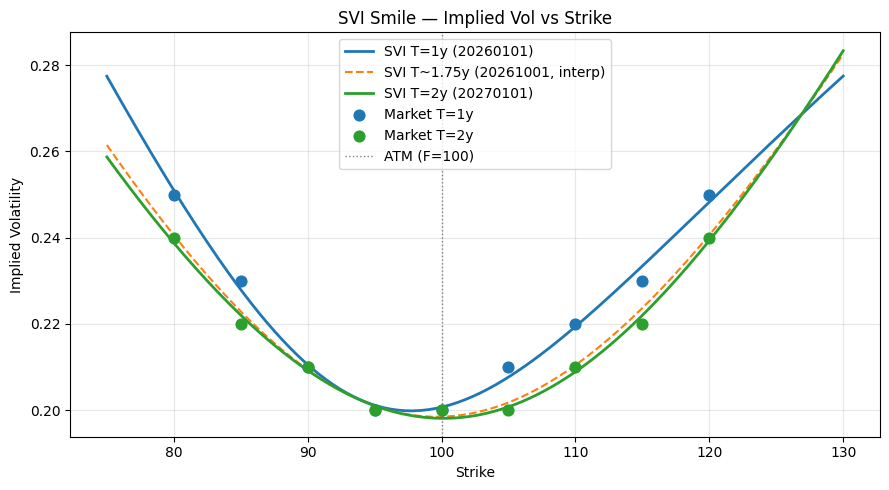

In [7]:
strike_grid = np.linspace(75, 130, 200)

smile1 = [slice1.implied_vol(K, forward, T1) for K in strike_grid]
smile2 = [slice2.implied_vol(K, forward, T2) for K in strike_grid]
smile_mid = [surface.get_vol(K, expiry_mid) for K in strike_grid]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strike_grid, smile1, label=f"SVI T=1y ({expiry1})", linewidth=2)
ax.plot(strike_grid, smile_mid, label=f"SVI T~1.75y ({expiry_mid}, interp)",
        linewidth=1.5, linestyle="--")
ax.plot(strike_grid, smile2, label=f"SVI T=2y ({expiry2})", linewidth=2)
ax.scatter(strikes, vols1, color="C0", zorder=5, label="Market T=1y", s=60)
ax.scatter(strikes, vols2, color="C2", zorder=5, label="Market T=2y", s=60)
ax.axvline(forward, color="grey", linestyle=":", linewidth=1, label="ATM (F=100)")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title("SVI Smile — Implied Vol vs Strike")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2 — Fitted vs Market Vols Scatter

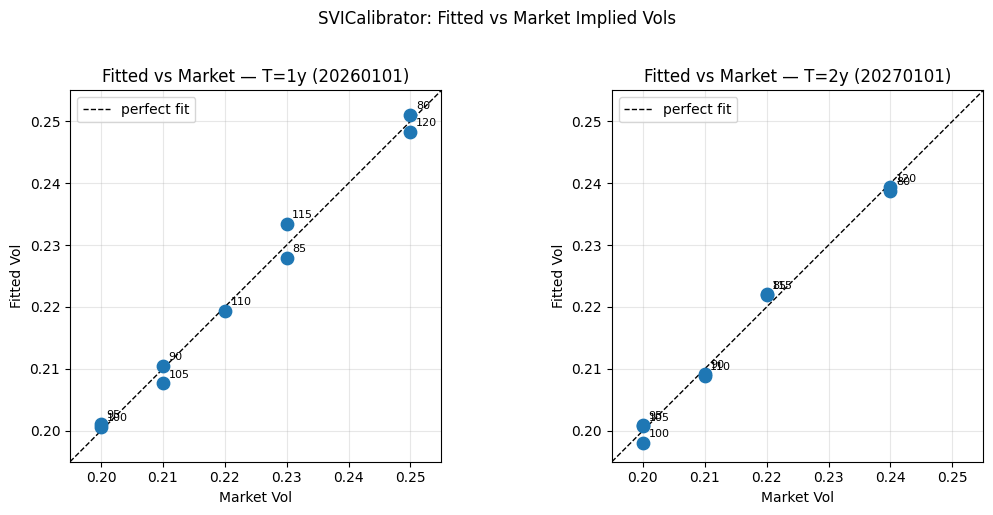

In [8]:
fitted1 = [slice1.implied_vol(K, forward, T1) for K in strikes]
fitted2 = [slice2.implied_vol(K, forward, T2) for K in strikes]

all_market = vols1 + vols2
all_fitted = fitted1 + fitted2
lo, hi = min(all_market) - 0.005, max(all_market) + 0.005

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, mkt, fit, label in [
    (axes[0], vols1, fitted1, f"T=1y ({expiry1})"),
    (axes[1], vols2, fitted2, f"T=2y ({expiry2})"),
]:
    ax.scatter(mkt, fit, s=80, zorder=5)
    for K, m, f in zip(strikes, mkt, fit):
        ax.annotate(str(K), (m, f), textcoords="offset points",
                    xytext=(4, 4), fontsize=8)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="perfect fit")
    ax.set_xlabel("Market Vol")
    ax.set_ylabel("Fitted Vol")
    ax.set_title(f"Fitted vs Market — {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

plt.suptitle("SVICalibrator: Fitted vs Market Implied Vols", y=1.02)
plt.tight_layout()
plt.show()

## Plot 3 — Vol Surface (Strikes x Expiry)

/tmp/ipykernel_421759/1845412573.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


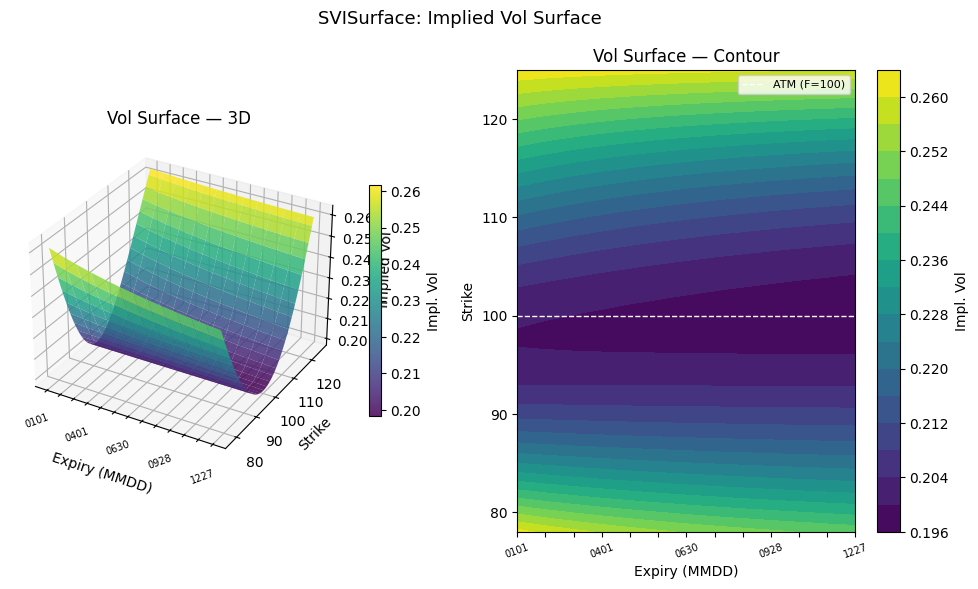

In [9]:
# Build a grid of (strike, expiry) -> implied vol via SVISurface.get_vol
# We sample 12 expiry dates evenly between the two calibrated expiries
from datetime import date, timedelta

def date_range_monthly(start: str, end: str, n: int = 13) -> list[str]:
    """Return n dates evenly spaced (by ordinal) between start and end inclusive."""
    d1 = date.fromisoformat(f"{start[:4]}-{start[4:6]}-{start[6:8]}")
    d2 = date.fromisoformat(f"{end[:4]}-{end[4:6]}-{end[6:8]}")
    step = (d2 - d1) / (n - 1)
    return [(d1 + timedelta(days=round(i * step.days))).strftime("%Y%m%d") for i in range(n)]

expiry_dates = date_range_monthly(expiry1, expiry2, n=13)
strike_grid = np.linspace(78, 125, 60)

vol_matrix = np.array(
    [[surface.get_vol(K, exp) for exp in expiry_dates] for K in strike_grid]
)

# x-axis: expiry index (we label by date); y-axis: strike
X, Y = np.meshgrid(range(len(expiry_dates)), strike_grid)

fig = plt.figure(figsize=(12, 6))

# --- Subplot A: 3-D surface ---
ax3d = fig.add_subplot(121, projection="3d")
surf = ax3d.plot_surface(X, Y, vol_matrix, cmap="viridis", alpha=0.85, edgecolor="none")
ax3d.set_xticks(range(len(expiry_dates)))
ax3d.set_xticklabels(
    [d[4:8] if i % 3 == 0 else "" for i, d in enumerate(expiry_dates)],
    fontsize=7, rotation=20
)
ax3d.set_xlabel("Expiry (MMDD)", labelpad=8)
ax3d.set_ylabel("Strike")
ax3d.set_zlabel("Implied Vol")
ax3d.set_title("Vol Surface — 3D")
fig.colorbar(surf, ax=ax3d, shrink=0.5, label="Impl. Vol")

# --- Subplot B: contour ---
ax2d = fig.add_subplot(122)
cs = ax2d.contourf(X, Y, vol_matrix, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax2d, label="Impl. Vol")
ax2d.set_xticks(range(len(expiry_dates)))
ax2d.set_xticklabels(
    [d[4:8] if i % 3 == 0 else "" for i, d in enumerate(expiry_dates)],
    fontsize=7, rotation=20
)
ax2d.set_xlabel("Expiry (MMDD)")
ax2d.set_ylabel("Strike")
ax2d.set_title("Vol Surface — Contour")
ax2d.axhline(forward, color="white", linestyle="--", linewidth=1, label="ATM (F=100)")
ax2d.legend(fontsize=8)

plt.suptitle("SVISurface: Implied Vol Surface", fontsize=13)
plt.tight_layout()
plt.show()